# Практическая работа 3. Рекуррентные нейронные сети

## Генерация текста на уровне символов с помощью LSTM и GRU

**Выполнил(а):** _________________________  (Фамилия И. О.)

**Группа:** _____________

**Преподаватель:** _____________

---

Цель работы — изучить рекуррентные нейронные сети (LSTM и GRU) на задаче генерации
текста. Модель учится предсказывать следующий символ по предыдущим и за счёт этого
порождает новый текст в стиле обучающих данных. В качестве данных взят корпус пьес
Шекспира (tiny shakespeare) — классический набор для посимвольных языковых моделей.

В работе обучается рекуррентная сеть, подбирается размер скрытого слоя, генерируется
текст с разной «температурой», сравниваются архитектуры LSTM, GRU и (для сравнения)
Transformer. Качество оценивается по функции потерь и перплексии на проверочной и
тестовой выборках.

## 1. Импорт библиотек и параметры запуска

In [1]:
import os
import time
import math
import random

import numpy as np
import requests
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [2]:
SEED = 42
DATA_URL = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
TEXT_LIMIT = None
SEQ_LEN = 100
BATCH = 64
EMBED = 128
HIDDEN_GRID = [128, 256]
EPOCHS_SEARCH = 2
EPOCHS = 6
NUM_LAYERS = 2
DROPOUT = 0.2
LR = 2e-3
NUM_WORKERS = 2

In [3]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = "cuda" if torch.cuda.is_available() else "cpu"
print("torch:", torch.__version__)
print("устройство:", device)

torch: 2.11.0+cu128
устройство: cuda


## 2. Загрузка данных

Текстовый корпус скачивается по публичной ссылке.

In [4]:
response = requests.get(DATA_URL, timeout=60)
response.raise_for_status()
text = response.text
if TEXT_LIMIT is not None:
    text = text[:TEXT_LIMIT]
assert len(text) > 1000, "корпус слишком короткий"
print("длина текста:", len(text))
print(text[:250])

длина текста: 1115394
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.



## 3. Предобработка

Строим словарь символов, кодируем текст числами и делим его на обучающую, проверочную и тестовую части по хронологии.

In [5]:
chars = sorted(set(text))
vocab_size = len(chars)
stoi = {c: i for i, c in enumerate(chars)}
itos = {i: c for i, c in enumerate(chars)}
encoded = np.array([stoi[c] for c in text], dtype=np.int64)

n = len(encoded)
train_data = encoded[: int(0.8 * n)]
val_data = encoded[int(0.8 * n): int(0.9 * n)]
test_data = encoded[int(0.9 * n):]
print("уникальных символов:", vocab_size)
print("train/val/test:", len(train_data), len(val_data), len(test_data))

уникальных символов: 65
train/val/test: 892315 111539 111540


## 4. Формирование последовательностей

Текст нарезается на куски фиксированной длины: вход — символы со сдвигом, цель — следующий символ.

In [6]:
class CharDataset(Dataset):
    def __init__(self, data, seq_len):
        self.data = torch.from_numpy(data)
        self.seq_len = seq_len

    def __len__(self):
        return (len(self.data) - 1) // self.seq_len

    def __getitem__(self, idx):
        i = idx * self.seq_len
        x = self.data[i: i + self.seq_len]
        y = self.data[i + 1: i + self.seq_len + 1]
        return x, y


def make_loader(data, shuffle, drop_last):
    g = torch.Generator()
    g.manual_seed(SEED)
    return DataLoader(CharDataset(data, SEQ_LEN), batch_size=BATCH, shuffle=shuffle,
                      num_workers=NUM_WORKERS, generator=g, drop_last=drop_last)


train_loader = make_loader(train_data, True, True)
val_loader = make_loader(val_data, False, False)
test_loader = make_loader(test_data, False, False)

## 5. Архитектуры моделей

Рекуррентная сеть (LSTM или GRU) и, для сравнения, компактный Transformer.

In [7]:
class CharRNN(nn.Module):
    def __init__(self, vocab_size, embed, hidden, num_layers, rnn_type, dropout):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed)
        rnn_cls = nn.LSTM if rnn_type == "LSTM" else nn.GRU
        self.rnn = rnn_cls(embed, hidden, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden, vocab_size)

    def forward(self, x, state=None):
        out, state = self.rnn(self.embed(x), state)
        return self.fc(out), state


class CharTransformer(nn.Module):
    def __init__(self, vocab_size, embed, nhead, num_layers, seq_len, dropout):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed)
        self.pos = nn.Parameter(torch.zeros(1, seq_len, embed))
        layer = nn.TransformerEncoderLayer(embed, nhead, embed * 4, dropout, batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(layer, num_layers, enable_nested_tensor=False)
        self.fc = nn.Linear(embed, vocab_size)

    def forward(self, x):
        length = x.size(1)
        mask = torch.triu(torch.ones(length, length, dtype=torch.bool, device=x.device), diagonal=1)
        h = self.embed(x) + self.pos[:, :length]
        h = self.transformer(h, mask=mask)
        return self.fc(h)

## 6. Функции обучения и оценки

Качество измеряется функцией потерь и перплексией.

In [8]:
criterion = nn.CrossEntropyLoss()


def run_epoch(model, loader, optimizer=None, is_rnn=True):
    training = optimizer is not None
    model.train() if training else model.eval()
    total_loss, total_tokens = 0.0, 0
    with torch.set_grad_enabled(training):
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)[0] if is_rnn else model(x)
            loss = criterion(out.reshape(-1, vocab_size), y.reshape(-1))
            if training:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            total_loss += loss.item() * y.numel()
            total_tokens += y.numel()
    avg = total_loss / total_tokens
    return avg, math.exp(avg)


def fit(model, epochs, lr, is_rnn=True, verbose=True):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"train_loss": [], "val_loss": [], "train_ppl": [], "val_ppl": []}
    for ep in range(1, epochs + 1):
        t0 = time.time()
        tl, tp = run_epoch(model, train_loader, optimizer, is_rnn)
        vl, vp = run_epoch(model, val_loader, None, is_rnn)
        history["train_loss"].append(tl)
        history["val_loss"].append(vl)
        history["train_ppl"].append(tp)
        history["val_ppl"].append(vp)
        if verbose:
            print(f"эпоха {ep}/{epochs} train_loss={tl:.3f} ppl={tp:.2f} val_loss={vl:.3f} ppl={vp:.2f} ({time.time() - t0:.0f} c)")
    return history

## 7. Подбор размера скрытого слоя по валидации

Перебираем несколько значений и выбираем лучшее по перплексии на проверочной выборке.

In [9]:
search_scores = {}
for hidden in HIDDEN_GRID:
    torch.manual_seed(SEED)
    model = CharRNN(vocab_size, EMBED, hidden, NUM_LAYERS, "LSTM", DROPOUT).to(device)
    hist = fit(model, EPOCHS_SEARCH, LR, verbose=False)
    search_scores[hidden] = min(hist["val_ppl"])
    print(f"hidden={hidden}, лучшая val_ppl={search_scores[hidden]:.2f}")

best_hidden = min(search_scores, key=search_scores.get)
print("выбранный размер скрытого слоя:", best_hidden)

hidden=128, лучшая val_ppl=7.02
hidden=256, лучшая val_ppl=5.81
выбранный размер скрытого слоя: 256


## 8. Обучение и сравнение архитектур

Обучаем LSTM, GRU и Transformer в сопоставимых условиях (одинаковое число эпох, один размер скрытого представления) и сравниваем по перплексии, числу параметров и времени.

In [10]:
def build(name):
    torch.manual_seed(SEED)
    if name == "Transformer":
        return CharTransformer(vocab_size, best_hidden, 4, NUM_LAYERS, SEQ_LEN, DROPOUT).to(device)
    return CharRNN(vocab_size, EMBED, best_hidden, NUM_LAYERS, name, DROPOUT).to(device)


histories = {}
results = []
for name in ["LSTM", "GRU", "Transformer"]:
    model = build(name)
    is_rnn = name != "Transformer"
    t0 = time.time()
    hist = fit(model, EPOCHS, LR, is_rnn=is_rnn, verbose=(name == "LSTM"))
    train_time = time.time() - t0
    test_loss, test_ppl = run_epoch(model, test_loader, None, is_rnn)
    n_params = sum(p.numel() for p in model.parameters()) / 1e6
    histories[name] = hist
    results.append({"модель": name, "параметры, млн": round(n_params, 2),
                    "val_ppl": round(min(hist["val_ppl"]), 2), "test_ppl": round(test_ppl, 2),
                    "время, с": round(train_time, 1)})
    if name == "LSTM":
        lstm_model = model
    if name == "GRU":
        gru_model = model

import pandas as pd
df = pd.DataFrame(results)
print(df.to_string(index=False))

эпоха 1/6 train_loss=2.425 ppl=11.31 val_loss=1.979 ppl=7.24 (3 c)
эпоха 2/6 train_loss=1.807 ppl=6.09 val_loss=1.747 ppl=5.74 (3 c)
эпоха 3/6 train_loss=1.632 ppl=5.11 val_loss=1.653 ppl=5.22 (3 c)
эпоха 4/6 train_loss=1.548 ppl=4.70 val_loss=1.599 ppl=4.95 (3 c)
эпоха 5/6 train_loss=1.495 ppl=4.46 val_loss=1.560 ppl=4.76 (3 c)
эпоха 6/6 train_loss=1.455 ppl=4.28 val_loss=1.542 ppl=4.67 (3 c)
     модель  параметры, млн  val_ppl  test_ppl  время, с
       LSTM            0.95     4.67      5.77      16.8
        GRU            0.72     4.43      5.37      13.6
Transformer            1.64     5.76      7.23      26.6


## 9. Графики обучения

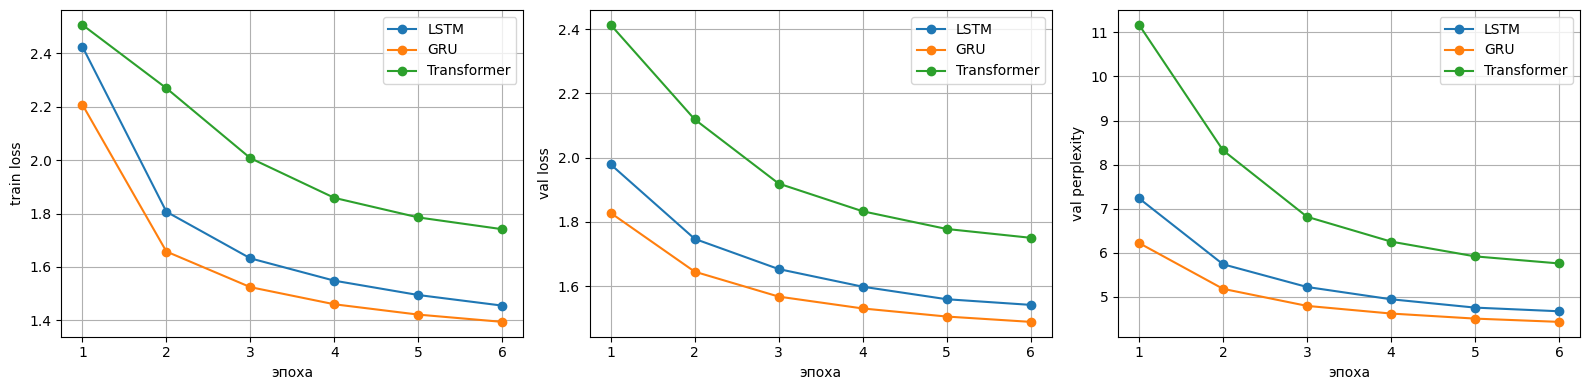

In [11]:
epochs_range = range(1, EPOCHS + 1)
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
for name, hist in histories.items():
    ax[0].plot(epochs_range, hist["train_loss"], "o-", label=name)
ax[0].set_ylabel("train loss")
ax[0].set_xlabel("эпоха")
ax[0].legend()
ax[0].grid(True)
for name, hist in histories.items():
    ax[1].plot(epochs_range, hist["val_loss"], "o-", label=name)
ax[1].set_ylabel("val loss")
ax[1].set_xlabel("эпоха")
ax[1].legend()
ax[1].grid(True)
for name, hist in histories.items():
    ax[2].plot(epochs_range, hist["val_ppl"], "o-", label=name)
ax[2].set_ylabel("val perplexity")
ax[2].set_xlabel("эпоха")
ax[2].legend()
ax[2].grid(True)
plt.tight_layout()
plt.show()

## 10. Генерация текста с разной температурой

Лучшая рекуррентная модель порождает текст из начального фрагмента. Кроме температурного семплирования показан вариант с top-k отбором кандидатов.

In [12]:
@torch.no_grad()
def generate(model, seed_text, length, temperature, top_k=None):
    model.eval()
    idx = [stoi[c] for c in seed_text]
    inp = torch.tensor([idx], device=device)
    out, state = model(inp)
    result = seed_text
    for _ in range(length):
        logits = out[0, -1] / temperature
        if top_k is not None:
            values, _ = torch.topk(logits, top_k)
            logits[logits < values[-1]] = float("-inf")
        probs = torch.softmax(logits, dim=-1)
        nxt = torch.multinomial(probs, 1)
        result += itos[int(nxt)]
        out, state = model(nxt.view(1, 1), state)
    return result


torch.manual_seed(SEED)
seed = "ROMEO:"
for temp in [0.5, 0.8, 1.0]:
    print(f"температура {temp}")
    print(generate(lstm_model, seed, 300, temp))
    print()

print("top-k семплирование, k=5, температура 0.8")
print(generate(lstm_model, seed, 300, 0.8, top_k=5))

температура 0.5
ROMEO:
The king, but the good lord, they do they will,
When I fear with his wife.

KING RICHARD III:
My lord, and the comfort the commits,
But he do say the rest than we fair,
And shall he is not the ore consent and make the compets
Of the prince and the said with the son
With the valion, that we cannot a

температура 0.8
ROMEO:
Sir, that we are by speak pervice;
Let your chear now of him your dispostitation
The rescens of thee from his bovoling,
His fathers, but not see it, and so take your man.

GLOUCESTER:
What are not; therefore is very ubder the life:
Do not, she be so trienction with then do a are.

RICHARD:
Besher, 

температура 1.0
ROMEO:
Nor nature coward is a swain
And Richard, thou ast to the luck account leave,
Low head England;
And longs and his grave, but this glorious marriege;
As is the sown and ends finds they of your speep it:
I myscent belivery and toery trive.

Nurse: Hath, could not
shall be no foremerts, whose house, c

top-k семплирование, k=5, те

## 11. Сравнение генерации LSTM и GRU

In [13]:
torch.manual_seed(SEED)
print("LSTM")
print(generate(lstm_model, seed, 250, 0.8))
print()
print("GRU")
print(generate(gru_model, seed, 250, 0.8))

LSTM
ROMEO:
Far I winter, 'twas your officer;
Would precking her forgot with lap with condemn,
And prevented than you, and you that man,
And what behind me with us that greater:
But I pretisuous winding upon it as in my wrengeness to
The man to thee make my can

GRU
ROMEO:
Say, as when God in Warwick, he, stay we cannot a time to be men,
Than what perpie to make some talks with him do?
I will that weeps mine own follow'd a denied by all
Is wish him; speak on my father, and I kill me,
I do pass of all himself thinking.


## Выводы и ответы на контрольные вопросы

### Как работает рекуррентная сеть

Рекуррентная сеть обрабатывает последовательность по одному элементу и хранит скрытое
состояние, которое передаётся на следующий шаг. За счёт этого сеть «помнит» контекст и
может предсказывать следующий символ по предыдущим. В нашей задаче на вход подаётся
кусок текста, а сеть учится угадывать каждый следующий символ; обученная модель затем
генерирует новый текст, подавая своё предсказание обратно на вход.

### Чем отличаются LSTM и GRU

Обычная рекуррентная сеть плохо запоминает длинные зависимости из-за затухания
градиентов. LSTM решает это с помощью ячейки памяти и трёх вентилей (входного, забывания
и выходного), которые управляют тем, что хранить и что забывать. GRU — более простой
вариант с двумя вентилями и без отдельной ячейки памяти, поэтому у него меньше
параметров и он обучается чуть быстрее. По таблице сравнения видно, что качество у LSTM
и GRU близкое, а GRU обычно немного легче.

### Перплексия и температура

Перплексия — это экспонента средней функции потерь; она показывает, насколько модель
«удивлена» правильным следующим символом. Чем перплексия ниже, тем лучше модель
предсказывает текст. Температура управляет разнообразием при генерации: при низкой
температуре модель выбирает наиболее вероятные символы и текст получается более
правильным, но однообразным, при высокой — текст разнообразнее, но в нём больше ошибок.

### Сравнение RNN и Transformer

Transformer обрабатывает всю последовательность сразу через механизм внимания, а не по
шагам, поэтому лучше работает с длинным контекстом и обучается параллельно. Рекуррентные
сети проще и экономнее по памяти, и на небольшом датасете и коротком контексте
показывают сопоставимое качество. По таблице сравнения видно соотношение перплексии,
числа параметров и времени обучения трёх архитектур; выбор зависит от объёма данных,
длины контекста и доступных ресурсов.